# Assignment 6

## Data Augmentation

Author: Samuel Fredric Berg

Student ID: sb224sc

Date: 2026-05-12

Course: Deep Machine Learning 4DT908

In [1]:
from numpy import zeros
from numpy import unique
from numpy import argmax
from numpy import asarray
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import Input

Train: X=(60000, 28, 28), y=(60000,)
Test: X=(10000, 28, 28), y=(10000,)


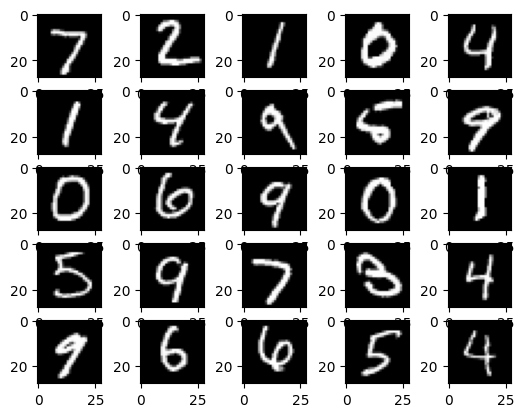

In [2]:
from tensorflow.keras.datasets.mnist import load_data
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = load_data()

print("Train: X=%s, y=%s" % (x_train.shape, y_train.shape))
print("Test: X=%s, y=%s" % (x_test.shape, y_test.shape))

for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(x_test[i], cmap=plt.get_cmap("gray"))

plt.show()

In [3]:
orig_shape = x_train.shape[1:]
x_train = x_train.reshape((x_train.shape[0], x_train.shape[1], x_train.shape[2], 1))
x_test = x_test.reshape((x_test.shape[0], x_test.shape[1], x_test.shape[2], 1))
in_shape = x_train.shape[1:]
print("Before: {0}".format(orig_shape))
print("After: {0}".format(in_shape))

n_classes = len(unique(y_train))
print("Classes: {0}".format(n_classes))

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

Before: (28, 28)
After: (28, 28, 1)
Classes: 10


In [9]:
EPOCHS = 10
BATCH_SIZE = 128
early_stopping = EarlyStopping(
    monitor="val_accuracy",
    patience=10,
    mode="max",
    restore_best_weights=True,
    verbose=1,
)

In [ ]:
def plot_metrics(history):
    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    metrics = ["loss", "accuracy"]
    plt.figure(figsize=(10, 5))
    for n, metric in enumerate(metrics):
        name = metric.replace("_", " ").capitalize()
        plt.subplot(1, 2, n + 1)
        plt.plot(history.epoch, history.history[metric], color=colors[0], label="Train")
        plt.plot(
            history.epoch,
            history.history["val_" + metric],
            color=colors[0],
            linestyle="--",
            label="Val",
        )
        plt.xlabel("Epoch")
        plt.ylabel(name)
        if metric == "loss":
            plt.ylim([0, plt.ylim()[1] + 0.1])
        else:
            plt.ylim([-0.1, 1.1])
        plt.legend()


def print_res(model):
    err = 0
    i_range = 10

    class bcolors:
        FAIL = "\033[91m"
        ENDC = "\033[0m"

    images = x_test[: i_range * i_range]
    yhats = model.predict(images, verbose=0)
    ys = argmax(yhats, axis=1)

    for i in range(i_range):
        for j in range(i_range):
            idx = i * i_range + j
            print("%d " % ys[idx], end="")
        print()
    print("--")
    for i in range(i_range):
        for j in range(i_range):
            idx = i * i_range + j
            y = y_test[idx]
            if y == ys[idx]:
                print("%d " % y, end="")
            else:
                err = err + 1
                print(f"{bcolors.FAIL}%d {bcolors.ENDC}" % y, end="")
        print()
    return err


### Model without data augmentation

A simple CNN with a single convolutional layer followed by max-pooling and a softmax output layer, trained directly on the raw MNIST training set.


In [6]:
def make_model1(add_dense=False):
    model = Sequential()
    model.add(Input(shape=in_shape))
    model.add(Conv2D(32, (9, 9), activation="relu"))
    model.add(MaxPooling2D((4, 4)))
    model.add(Flatten())
    if add_dense:
        model.add(Dense(30, activation="relu"))
        model.add(Dropout(0.2))
    model.add(Dense(n_classes, activation="softmax"))
    model.compile(
        optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
    )
    return model


model = make_model1(False)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 20, 20, 32)     │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         8,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,634 (41.54 KB)

 Trainable params: 10,634 (41.54 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
model_history = model.fit(
    x_train,
    y_train,
    epochs=EPOCHS,
    callbacks=[early_stopping],
    validation_data=(x_test, y_test),
    batch_size=BATCH_SIZE,
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9089 - loss: 0.3549 - val_accuracy: 0.9654 - val_loss: 0.1198
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9721 - loss: 0.0951 - val_accuracy: 0.9784 - val_loss: 0.0730
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9798 - loss: 0.0689 - val_accuracy: 0.9826 - val_loss: 0.0525
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9835 - loss: 0.0556 - val_accuracy: 0.9825 - val_loss: 0.0538
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9855 - loss: 0.0477 - val_accuracy: 0.9856 - val_loss: 0.0425
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9873 - loss: 0.0426 - val_accuracy: 0.9872 - val_loss: 0.0409
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9886 - loss: 0.0377 - val_accuracy: 0.9874 - val_loss: 0.0384
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9889 - loss: 0.0348 - val_accuracy: 0.

Accuracy: 0.988
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
9 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
4 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

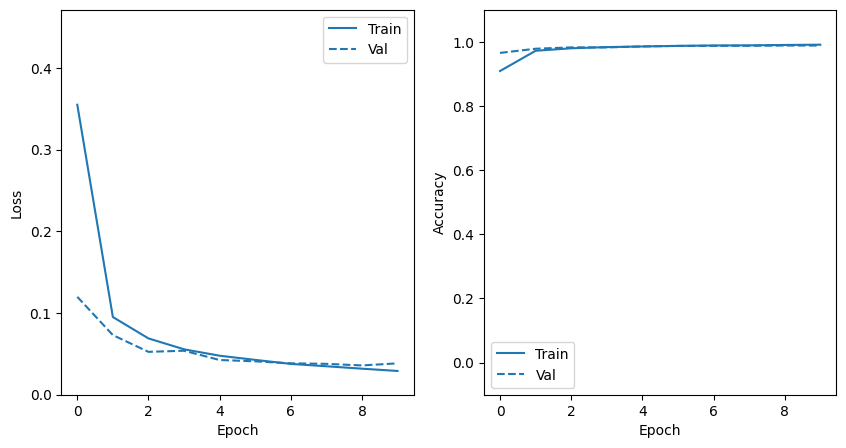

In [8]:
plot_metrics(model_history)
loss, acc = model.evaluate(x_test, y_test, verbose=0)
print("Accuracy: %.3f" % acc)
err = print_res(model)

The baseline model achieves reasonable accuracy on MNIST with minimal architecture.
Without data augmentation the model trains only on the fixed training set, which may lead to slight overfitting on more complex datasets.


### Model with data augmentation

A deeper CNN with two convolutional layers and a dense hidden layer, trained with on-the-fly data augmentation (random zoom and rotation) to improve generalisation.
Horizontal flipping is intentionally omitted because MNIST digits are not horizontally symmetric.


In [10]:
def make_model2(add_dense=False):
    model = Sequential()
    model.add(Input(shape=in_shape))
    model.add(Conv2D(64, (5, 5), activation="relu"))
    model.add(MaxPooling2D((4, 4)))
    model.add(Conv2D(16, (3, 3), activation="relu"))
    model.add(MaxPooling2D((2, 2)))
    model.add(Flatten())
    if add_dense:
        model.add(Dense(100, activation="relu"))
        model.add(Dropout(0.3))
    model.add(Dense(n_classes, activation="softmax"))
    model.compile(
        optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
    )
    return model


model = make_model2(True)
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 16)       │         9,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │         6,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,406 (71.90 KB)

 Trainable params: 18,406 (71.90 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
datagen = ImageDataGenerator(zoom_range=0.1, rotation_range=10)

train_generator = datagen.flow(x_train, y_train, batch_size=16)

model_history = model.fit(
    train_generator,
    epochs=EPOCHS,
    callbacks=[early_stopping],
    validation_data=(x_test, y_test),
)


Accuracy: 0.982
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
9 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
4 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

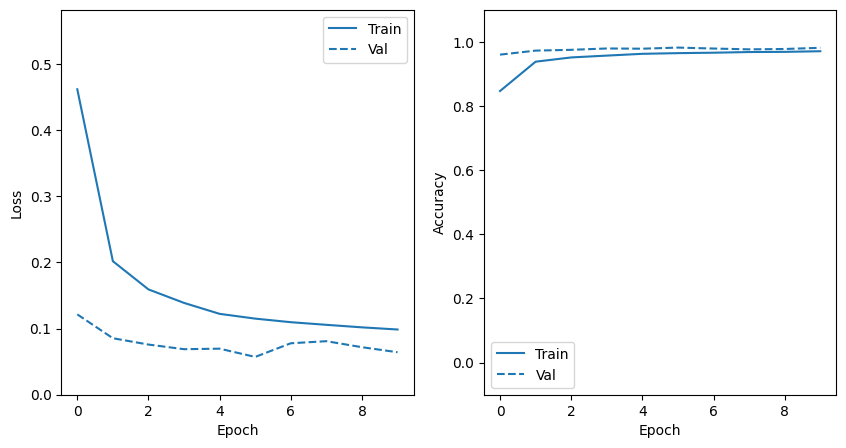

In [12]:
plot_metrics(model_history)
loss, acc = model.evaluate(x_test, y_test, verbose=0)
print("Accuracy: %.3f" % acc)
err = print_res(model)

Data augmentation with zoom and rotation increases the effective training set size and improves generalisation.
The deeper architecture with dropout further reduces overfitting.
The augmented model should achieve higher or equal accuracy compared to the baseline while being more robust.
